$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 15 de Maio de 2026   

$ \textbf{Estudo Orientado - 2026.1}$

In [51]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon
import numdifftools as nd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.stattools import acf, pacf
from naveau_model import NaveauModelI as naveau

In [2]:
rng = np.random.default_rng(seed=4)

In [18]:
path_results = r'C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas'

# Bernoulli-Gamma

$$ 
\begin{align}
    f(y_t|y_{t-1}) &= (1-\pi)*(1-I_{y_t>0}) + \pi*g(y_t|y_{t-1})*I_{y_t>0}, \quad onde \\
    g(y_t|y_{t-1}) &\sim \text{Gamma}(\alpha, \theta) \\
\end{align}
$$ 

## Simulação

In [ ]:
pi = 0.7
alpha = 2
theta = 10 # escala
n_sim = int(1e5) # simulações

dates = pd.date_range(start='2001-01-01', end='2025-12-31', freq='ME')
T = len(dates)

gamma_points = rng.gamma(shape=alpha, scale=theta, size=(n_sim,T))
bernoulli_points = rng.binomial(n=1, p=pi, size=(n_sim,T))
simulated_points = bernoulli_points * gamma_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )
df_sim = pd.DataFrame(simulated_points[:5,:].T, index=dates, columns=[f'sim_{i+1}' for i in range(5)])

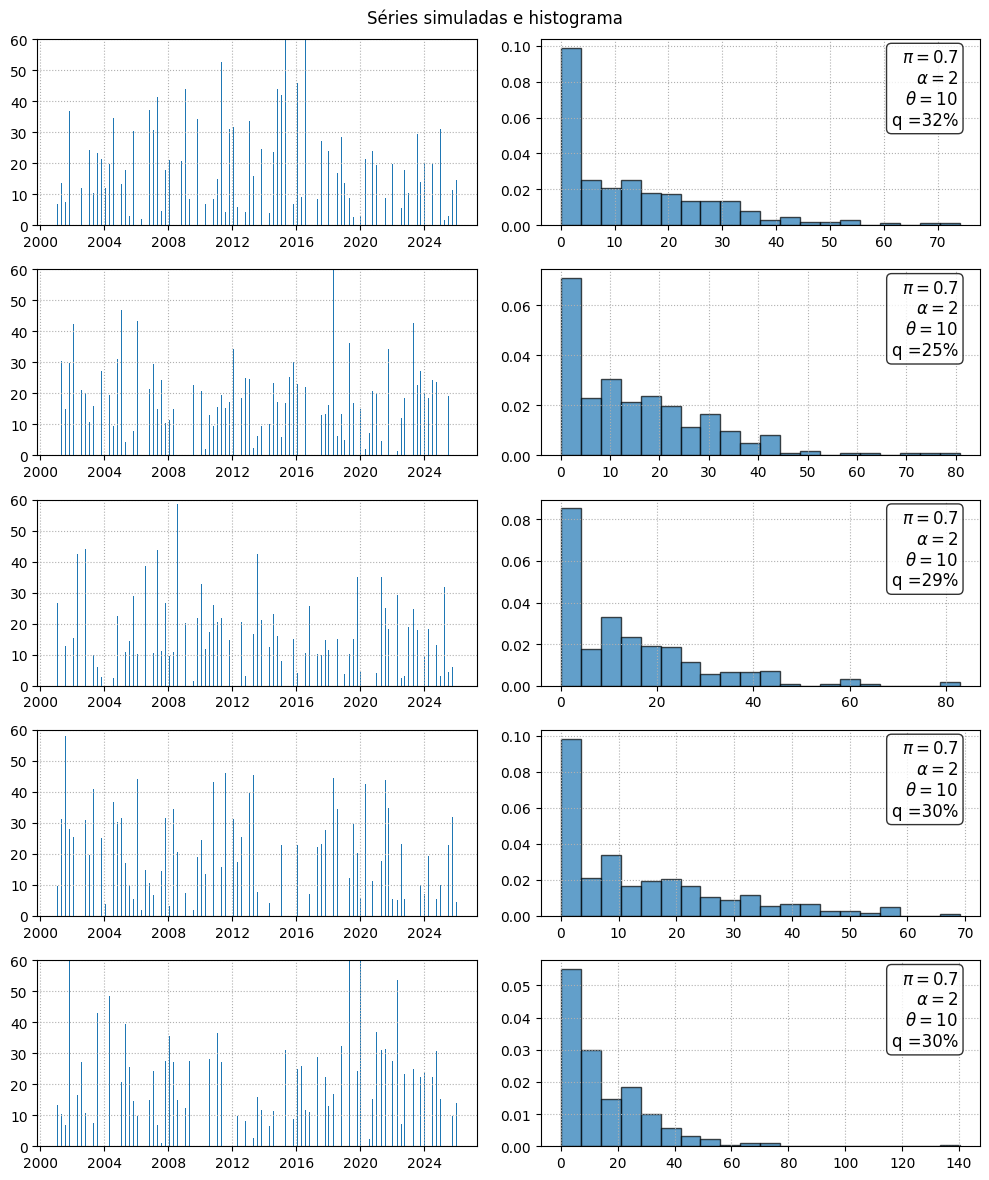

In [190]:
# séries simuladas
fig, ax = plt.subplots(df_sim.shape[1],2,figsize=(10,12))
for i in range(df_sim.shape[1]):
    df_plot = df_sim.iloc[:,i]
    textstr = f'$\pi={pi}$\n$\\alpha={alpha}$\n$\\theta={theta}$'
    
    ax[i][0].bar(df_plot.index, df_plot, width=8)
    ax[i][0].set_ylim(top=60)
    ax[i][0].grid(axis='both', linestyle=':')
            
    ax[i][1].hist(df_plot, bins=20, density=True, alpha=0.7, edgecolor='black')
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax[i][1].text(0.95, 0.95, textstr, transform=ax[i][1].transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='right', bbox=props)
    ax[i][1].grid(axis='both', linestyle=':')

fig.suptitle('Séries simuladas e histograma'.format(alpha))
fig.tight_layout()
plt.show()

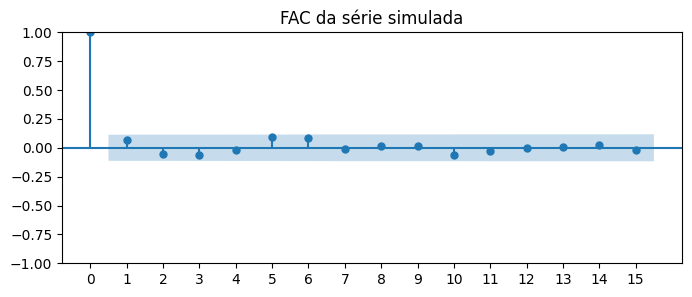

In [193]:
# FAC de uma série simulada
fig, ax = plt.subplots(figsize=(8,3))
lags=15
plot_acf(df_sim.iloc[:,0],lags=lags, ax=ax, title=f'FAC da série')
ax.set_xticks(np.arange(lags+1))
ax.set_xticklabels(np.arange(lags+1))
ax.set_title('FAC da série simulada')
plt.show()

## Estimação

In [188]:
# estimação
estimates = np.zeros((n_sim,3))
for i in tqdm(range(1)):
    y = simulated_points[i,:]
    pi_hat = np.mean(y>0) # n_pos/T
    alpha_hat, loc_hat, theta_hat = gamma.fit(y[y>0], floc=0)
    estimates[i,:] = [pi_hat, alpha_hat, theta_hat]

Dados simulados com 300 observações de Jan 2001 a Dec 2025


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 7999.84it/s]


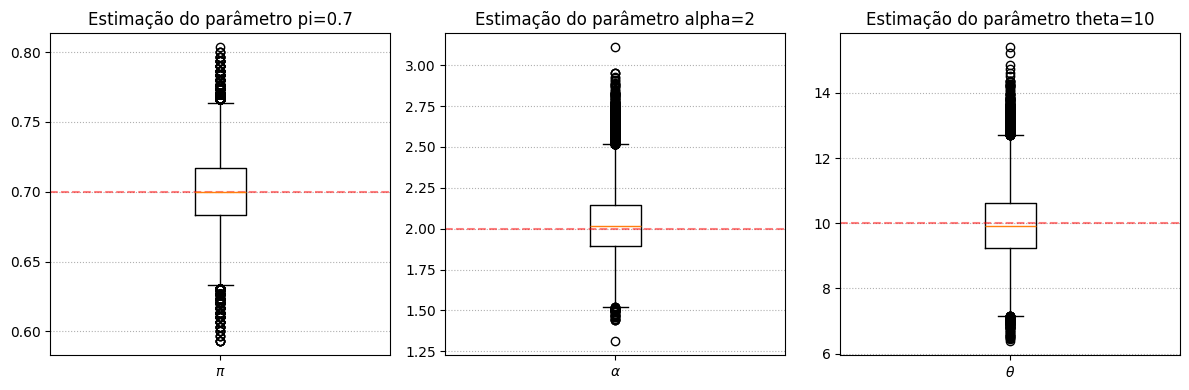

In [189]:
# plot das estimações
fig, ax = plt.subplots(1,3,figsize=(12,4))

params = [f'pi={pi}',f'alpha={alpha}',f'theta={theta}']
for i in range(3):
    ax[i].boxplot(estimates[:,i])
    ax[i].set_title(f'Estimação do parâmetro {params[i]}')
    ax[i].grid(axis='y', linestyle=':')
    ax[i].set_xticklabels([r'$\{}$'.format(params[i].split('=')[0])])
    ax[i].axhline([pi, alpha, theta][i], color='red', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

# ZIEGPD (naveau m1)

$$ 
\begin{align}
    F(y) &= (1-\pi)(1-I_{y>0}) + \pi\, G(y)\,I_{y>0}, \quad onde \\
    G(y) &= \mathcal{W}\left\{
                H_\xi\left(\dfrac{y}{\sigma}\right)
            \right\}, \qquad \sigma>0 \qquad com\\
    \mathcal{W}(v) &= v^\kappa, \qquad \kappa>0
\end{align}
$$ 

## Simulação

In [41]:
pi = 0.7
kappa = 2
sigma = 5
xi = 0.2
n_sim = int(1e5) # simulações

dates = pd.date_range(start='2001-01-01', end='2025-12-31', freq='ME')
T = len(dates)

model = naveau(kappa=kappa, sigma=sigma, xi=xi)
egpd_points = model.rvs(size=(n_sim,T))
bernoulli_points = rng.binomial(n=1, p=pi, size=(n_sim,T))
simulated_points = bernoulli_points * egpd_points

print('Dados simulados com {} observações de {} a {}'.format(
    T, dates[0].strftime('%b %Y'), dates[-1].strftime('%b %Y'))
     )
df_sim = pd.DataFrame(simulated_points[:5,:].T, index=dates, columns=[f'sim_{i+1}' for i in range(5)])

Dados simulados com 300 observações de Jan 2001 a Dec 2025


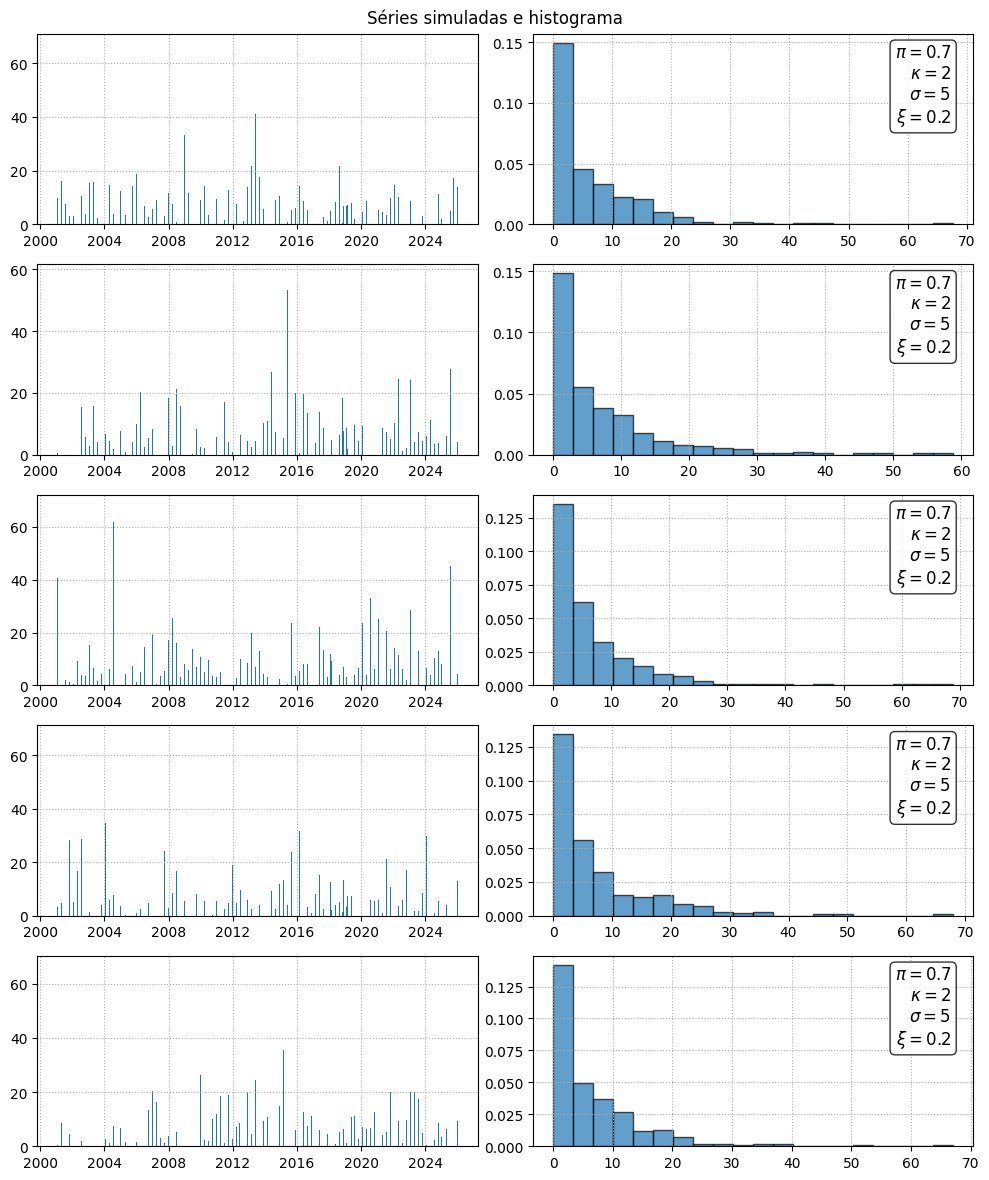

In [42]:
# séries simuladas
fig, ax = plt.subplots(df_sim.shape[1],2,figsize=(10,12))
for i in range(df_sim.shape[1]):
    df_plot = df_sim.iloc[:,i]
    q_zeros = (df_plot == 0).sum() / len(df_plot)
    textstr = f'$\pi={pi}$\n$\\kappa={kappa}$\n$\\sigma={sigma}$\n$\\xi={xi}$'
    
    ax[i][0].bar(df_plot.index, df_plot, width=8)
    ax[i][0].grid(axis='both', linestyle=':')
            
    ax[i][1].hist(df_plot, bins=20, density=True, alpha=0.7, edgecolor='black')
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax[i][1].text(0.95, 0.95, textstr, transform=ax[i][1].transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='right', bbox=props)
    ax[i][1].grid(axis='both', linestyle=':')

fig.suptitle('Séries simuladas e histograma')
fig.tight_layout()
plt.show()

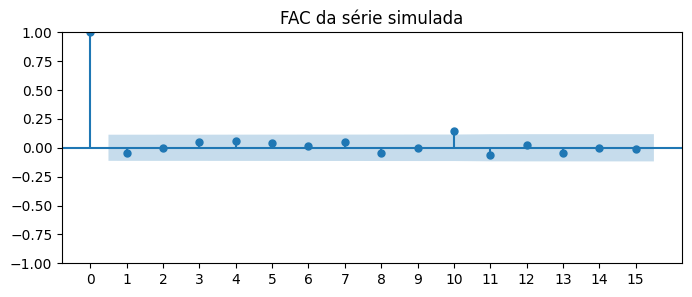

In [43]:
# FAC de uma série simulada
fig, ax = plt.subplots(figsize=(8,3))
lags=15
plot_acf(df_sim.iloc[:,0],lags=lags, ax=ax, title=f'FAC da série')
ax.set_xticks(np.arange(lags+1))
ax.set_xticklabels(np.arange(lags+1))
ax.set_title('FAC da série simulada')
plt.show()

## Estimação

In [85]:
# estimação
estimates = np.zeros((n_sim,4))
for i in tqdm(range(n_sim)):
    y = simulated_points[i,:]
    pi_hat = np.mean(y>0) # proporção de dias com chuva
    model_fit = naveau.fit(y[y>0]) # EGPD estimada nos dados positivos
    estimates[i,:] = [pi_hat, model_fit.kappa, model_fit.sigma, model_fit.xi]

# salvar resultados
pd.DataFrame(
    estimates, columns=[f'pi={pi}',f'kappa={kappa}',f'sigma={sigma}',f'xi={xi}']
).to_csv(path_results + r'\estimates_naveau_{}.csv'.format(datetime.now().strftime('%Y%m%d')), index=False)

# carregar resultados anteriores
estimates_df = pd.read_csv(path_results + r'\estimates_naveau_{}.csv'.format(datetime.now().strftime('%Y%m%d')))
# estimates = estimates_df.values

  0%|                                                                              | 33/100000 [00:00<32:28, 51.31it/s]C:\Users\aless\Desktop\Codes\venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [26:41<00:00, 62.44it/s]


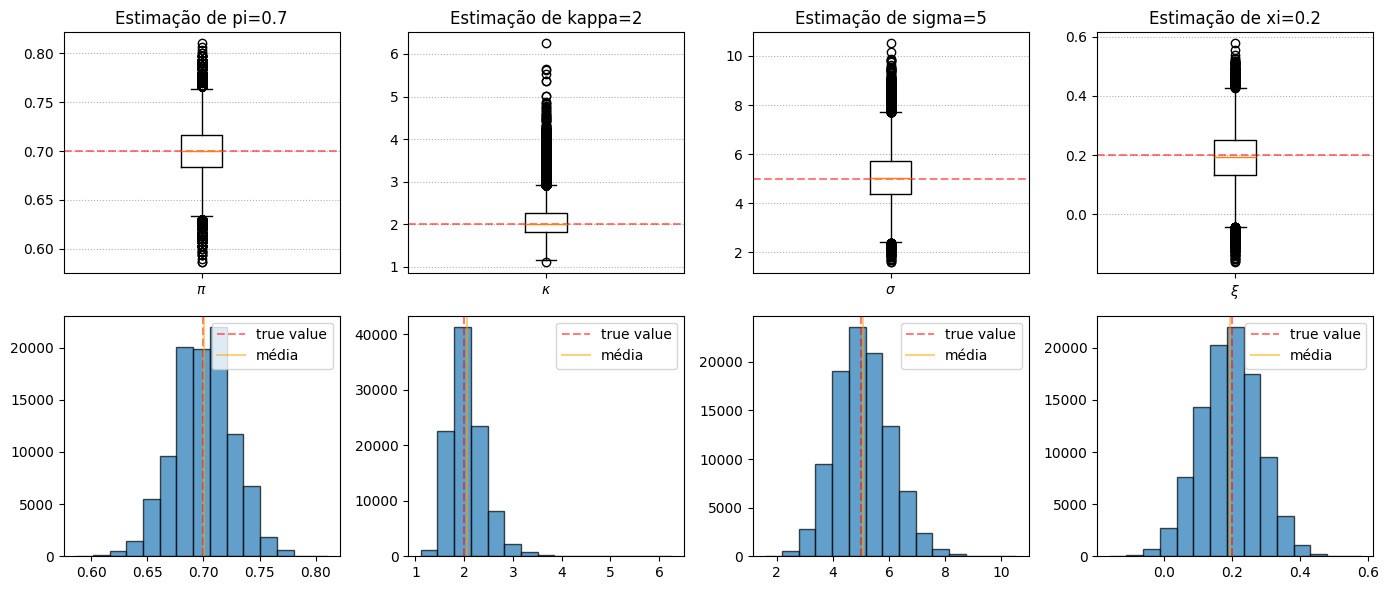

In [90]:
# plot das estimações
fig, ax = plt.subplots(2,4,figsize=(14,6))

# params = [f'kappa={kappa}',f'sigma={sigma}',f'xi={xi}']
params = estimates_df.columns.values
for i in range(4):
    ax[0][i].boxplot(estimates[:,i])
    ax[0][i].set_title(f'Estimação de {params[i]}')
    ax[0][i].grid(axis='y', linestyle=':')
    ax[0][i].set_xticklabels([r'$\{}$'.format(params[i].split('=')[0])])
    ax[0][i].axhline([pi, kappa, sigma, xi][i], color='red', linestyle='--', alpha=0.5)

    ax[1][i].hist(estimates[:,i], bins=15, density=False, alpha=0.7, edgecolor='black')
    ax[1][i].axvline([pi, kappa, sigma, xi][i], color='red', linestyle='--', alpha=0.5, label='true value')
    ax[1][i].axvline(np.mean(estimates[:,i]), color='orange', linestyle='-', alpha=0.5, label='média')
    ax[1][i].legend()

fig.tight_layout()
plt.show()